In [463]:
from io import StringIO

import pandas as pd
import requests
import seaborn
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

In [464]:
api_url = 'https://uk.wikipedia.org/w/api.php'
params = {
    'action': 'parse',
    'page': 'Населення України',
    'prop': 'text',
    'format': 'json'
}
r = requests.get(api_url, params=params)
html = r.json()['parse']['text']['*']
soup = BeautifulSoup(html, 'html.parser')


captions = soup.select('caption')
table_caption = [caption for caption in captions if caption.text.startswith('Коефіцієнт народжуваності')][0]
table = table_caption.parent


df = pd.read_html(StringIO(str(table)))[0]
df.set_index('Регіон', inplace=True)
df

,1950,1960,1970,1990,2000,2012,2014,2019
Регіон,,,,,,,,
Крим,230.0,206.0,160.0,130,73,126,—,—
Вінницька,224.0,192.0,142.0,124,84,112,109,76
Волинська,247.0,250.0,179.0,153,112,148,141,101
Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
Донецька,271.0,214.0,140.0,109,61,98,82,—
Житомирська,261.0,223.0,159.0,129,89,122,120,79
Закарпатська,314.0,273.0,207.0,168,115,151,146,104
Запорізька,219.0,197.0,150.0,124,71,106,106,68
Івано-Франківська,243.0,248.0,182.0,155,103,124,122,88


Вивести перші рядки таблиці за допомогою методу `head`.

In [465]:
df.head()

,1950,1960,1970,1990,2000,2012,2014,2019
Регіон,,,,,,,,
Крим,230.0,206.0,160.0,130,73,126,—,—
Вінницька,224.0,192.0,142.0,124,84,112,109,76
Волинська,247.0,250.0,179.0,153,112,148,141,101
Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
Донецька,271.0,214.0,140.0,109,61,98,82,—


Визначте кількість рядків та стовпців у датафреймі за допомогою атрибута `shape`.

In [466]:
rows, cols = df.shape
print(f"Columns: {cols}, Rows: {rows}")

Columns: 8, Rows: 28


Замініть у таблиці значення `"—"` на значення `NaN`.

In [467]:
df.replace('—', pd.NA, inplace=True)

,1950,1960,1970,1990,2000,2012,2014,2019
Регіон,,,,,,,,
Крим,230.0,206.0,160.0,130,73,126,NaN,NaN
Вінницька,224.0,192.0,142.0,124,84,112,109,76
Волинська,247.0,250.0,179.0,153,112,148,141,101
Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
Донецька,271.0,214.0,140.0,109,61,98,82,NaN
Житомирська,261.0,223.0,159.0,129,89,122,120,79
Закарпатська,314.0,273.0,207.0,168,115,151,146,104
Запорізька,219.0,197.0,150.0,124,71,106,106,68
Івано-Франківська,243.0,248.0,182.0,155,103,124,122,88


Визначте типи всіх стовпців за допомогою `dataframe.dtypes`.

In [468]:
df.dtypes

1950    float64
1960    float64
1970    float64
1990      int64
2000      int64
2012      int64
2014        str
2019        str
dtype: object

Замініть типи нечислових колонок на числові. Підказка: це колонки, де знаходився символ `"—"`.

In [469]:
cols_to_convert = df.dtypes[df.dtypes == 'str'].index
df[cols_to_convert] = df[cols_to_convert].astype('Float64')
df.dtypes

1950    float64
1960    float64
1970    float64
1990      int64
2000      int64
2012      int64
2014    Float64
2019    Float64
dtype: object

Порахуйте, яка частка пропусків міститься в кожній колонці, використовуючи методи `isnull` та `sum`.

In [470]:
df[df.columns].isnull().sum() / df.shape[0]

1950    0.071429
1960    0.035714
1970    0.035714
1990    0.000000
2000    0.000000
2012    0.000000
2014    0.071429
2019    0.142857
dtype: float64

Видаліть з таблиці дані по всій країні — останній рядок таблиці.

In [471]:
df.drop(axis=0, index=df.index[-1], inplace=True)
df

,1950,1960,1970,1990,2000,2012,2014,2019
Регіон,,,,,,,,
Крим,230.0,206.0,160.0,130,73,126,<NA>,<NA>
Вінницька,224.0,192.0,142.0,124,84,112,109.0,76.0
Волинська,247.0,250.0,179.0,153,112,148,141.0,101.0
Дніпропетровська,204.0,204.0,151.0,123,71,112,111.0,71.0
Донецька,271.0,214.0,140.0,109,61,98,82.0,<NA>
Житомирська,261.0,223.0,159.0,129,89,122,120.0,79.0
Закарпатська,314.0,273.0,207.0,168,115,151,146.0,104.0
Запорізька,219.0,197.0,150.0,124,71,106,106.0,68.0
Івано-Франківська,243.0,248.0,182.0,155,103,124,122.0,88.0


Замініть відсутні дані в стовпцях середніми значеннями цих стовпців за допомогою методу `fillna`.

In [472]:
fill_values = {col: df[col].mean() for col in df.columns}
df.fillna(value=fill_values, inplace=True)

,1950,1960,1970,1990,2000,2012,2014,2019
Регіон,,,,,,,,
Крим,230.00,206.000000,160.0,130,73,126,111.44,80.173913
Вінницька,224.00,192.000000,142.0,124,84,112,109.0,76.0
Волинська,247.00,250.000000,179.0,153,112,148,141.0,101.0
Дніпропетровська,204.00,204.000000,151.0,123,71,112,111.0,71.0
Донецька,271.00,214.000000,140.0,109,61,98,82.0,80.173913
Житомирська,261.00,223.000000,159.0,129,89,122,120.0,79.0
Закарпатська,314.00,273.000000,207.0,168,115,151,146.0,104.0
Запорізька,219.00,197.000000,150.0,124,71,106,106.0,68.0
Івано-Франківська,243.00,248.000000,182.0,155,103,124,122.0,88.0


Отримайте список регіонів, де рівень народжуваності у 2019 році був вищим за середній по Україні.

In [473]:
df.where(df['2019'] > df['2019'].mean()).dropna()

,1950,1960,1970,1990,2000,2012,2014,2019
Регіон,,,,,,,,
Волинська,247.00,250.0,179.0,153.0,112.0,148.0,141.0,101.0
Закарпатська,314.00,273.0,207.0,168.0,115.0,151.0,146.0,104.0
Івано-Франківська,243.00,248.0,182.0,155.0,103.0,124.0,122.0,88.0
Львівська,234.00,240.0,171.0,140.0,91.0,119.0,119.0,87.0
Одеська,241.00,192.0,148.0,126.0,80.0,127.0,123.0,88.0
Рівненська,269.00,267.0,193.0,158.0,118.0,159.0,148.0,107.0
Херсонська,208.00,214.0,166.0,143.0,85.0,117.0,115.0,81.0
Чернівецька,247.00,218.0,170.0,148.0,101.0,128.0,129.0,92.0
Київ,231.04,174.0,159.0,120.0,73.0,120.0,121.0,110.0


У якому регіоні була найвища народжуваність у 2014 році? <br/>
Відповідь: Рівненська, 148

In [474]:
df[['2014']].sort_values(by='2014', ascending=False).iloc[0]

2014    148.0
Name: Рівненська, dtype: Float64

Побудуйте стовпчикову діаграму народжуваності по регіонах у 2019 році.

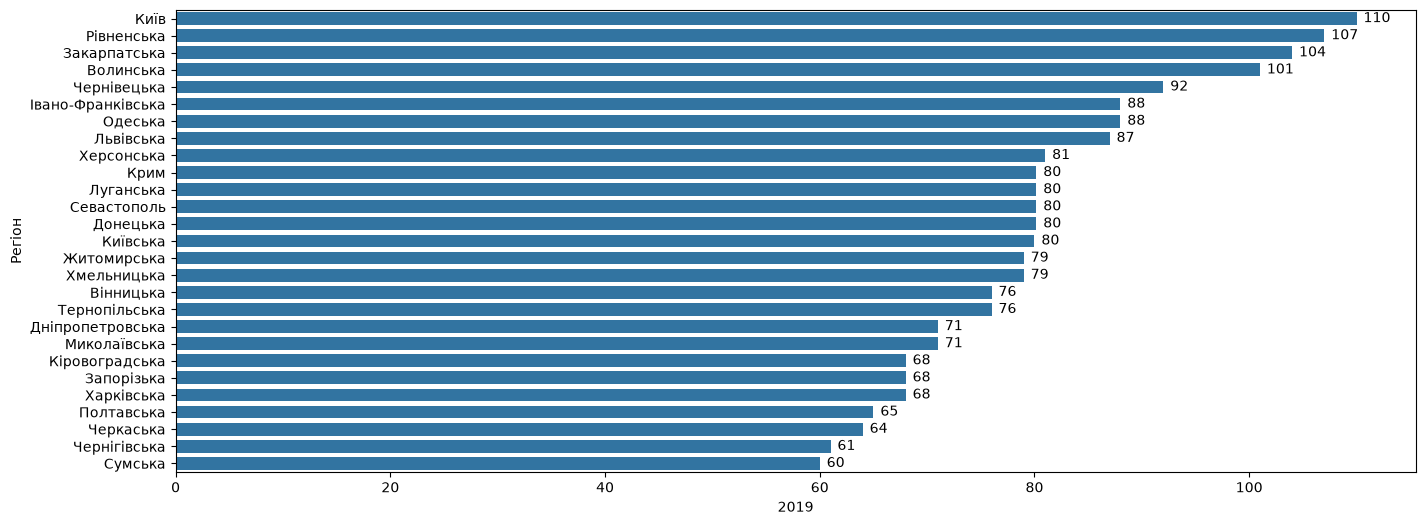

In [475]:
sub_df = df[['2019']].sort_values(by='2019', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
ax = seaborn.barplot(orient='h', data=sub_df, x='2019', y=sub_df.index, width=0.75)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=5)

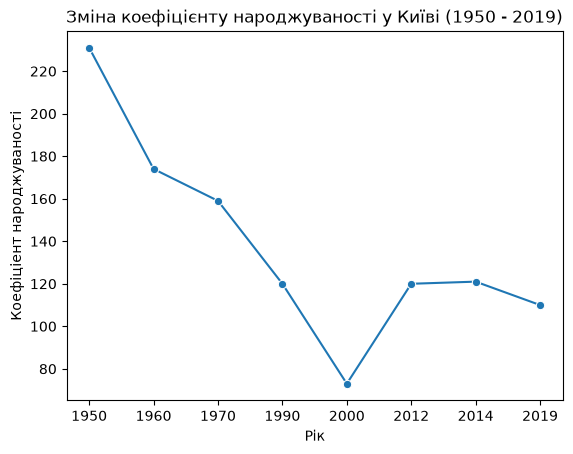

In [476]:
g = seaborn.lineplot(data=df.loc['Київ'], marker='o')
plt.title(f'Зміна коефіцієнту народжуваності у Київі ({df.columns[0]} - {df.columns[-1]})')
plt.ylabel('Коефіціент народжуваності')
plt.xlabel('Рік')
plt.show()

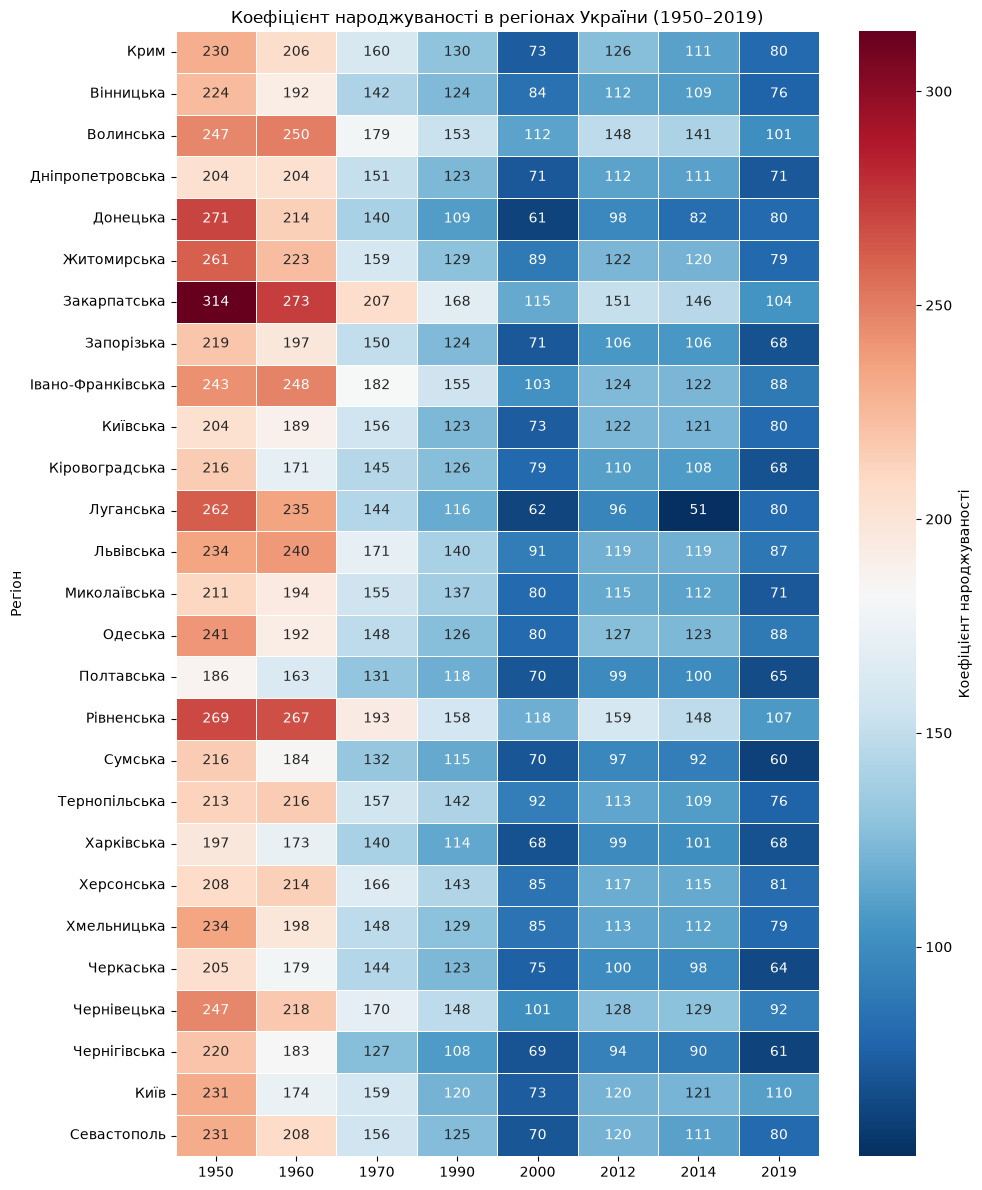

In [483]:
cols_to_convert = df.dtypes[df.dtypes != 'float64'].index
df[cols_to_convert] = df[cols_to_convert].astype('float64')

plt.figure(figsize=(10, 12))
seaborn.heatmap(df, cmap="RdBu_r", annot=True, fmt=".0f", linewidths=0.5, cbar_kws={"label": "Коефіцієнт народжуваності"})
plt.title("Коефіцієнт народжуваності в регіонах України (1950–2019)")
plt.tight_layout()